
# AmbiCode-Eval — Milestone Analysis

**How do SOTA LLMs handle linguistically ambiguous coding prompts?**

This notebook reports the first cross-model evaluation of *AmbiCode-Eval*,
a benchmark of 48 coding tasks where a single linguistic ambiguity has
been injected into an otherwise clear prompt. Each task admits two distinct
valid programmatic interpretations (A and B), with associated reference
solutions and unit tests. We measure:

1. **Ambiguity Tax** — `pass@k(clean) − pass@k(perturbed)`, where pass@k
   under perturbation counts a sample as successful if it satisfies *either*
   interpretation A or B.
2. **Behavioral profile** — Silent Assumption / Explicit Assumption /
   Active Clarification.
3. **Interpretation bias** — among samples that satisfy exactly one of A or B,
   what fraction picks A?

We evaluate **5 SOTA models** at temperature 0.8 with n=5 samples per item.

| Model | Provider | Reasoning? |
|---|---|---|
| GPT-5.5 | OpenAI | no |
| Claude Sonnet 4.6 | Anthropic | no |
| Claude Opus 4.6 | Anthropic | no |
| Gemini 3.1 Pro | Google | yes |
| DeepSeek V4 Pro | DeepSeek | yes |

> *Qwen 3.6 Plus was attempted but throughput made full evaluation impractical for this milestone.*


In [1]:

# ── Setup ──────────────────────────────────────────────────────────────────
import json
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

# Make sure project root is importable for plot_style
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from scripts.plot_style import (
    setup_style, MODEL_COLORS, MODEL_ORDER, TYPE_COLORS, BEHAVIOR_COLORS,
    DIVERGING_CMAP,
    model_palette, model_order, annotate_bars, add_zero_line, save_for_poster,
    shorten_model_name,
)

setup_style()

# ── Load milestone data ────────────────────────────────────────────────────
DATA = ROOT / "data" / "results" / "milestone"
summary    = json.loads((DATA / "summary.json").read_text())
per_item   = pd.read_csv(DATA / "per_item.csv")
by_type    = pd.read_csv(DATA / "by_type.csv")
by_risk    = pd.read_csv(DATA / "by_risk.csv")
by_source  = pd.read_csv(DATA / "by_source.csv")

# Restrict to milestone models in the canonical project order
MODELS = [m for m in MODEL_ORDER if m in summary["models"]]
print(f"Loaded {len(MODELS)} models: {MODELS}")
print(f"Benchmark: {summary['benchmark_size']} items "
      f"({per_item.groupby('source')['task_id'].nunique().to_dict()})")


Loaded 5 models: ['gpt-5.5', 'claude-sonnet', 'claude-opus', 'gemini-3.1-pro', 'deepseek-v4-pro']
Benchmark: 48 items ({'ds1000': 27, 'humaneval': 2, 'mbpp': 19})


In [2]:

# ── Sample-level loader ────────────────────────────────────────────────────
# Some analyses (latency × behavior, EA's interpretation choice) need
# per-sample data. Load only the fields we need from classified_*.jsonl
# (skip raw_response / generated_code to keep memory light).
_TS_RE = re.compile(r"_(\d{8}_\d{6})\.jsonl$")
def _ts(p): m = _TS_RE.search(p.name); return m.group(1) if m else ""

def _load_classified_for(model):
    safe = model.replace("/", "_")
    candidates = sorted((ROOT / "data/results").glob(f"classified_{safe}_*.jsonl"),
                        key=_ts, reverse=True)
    for c in candidates:
        rows = []
        for line in c.read_text().splitlines():
            if not line.strip():
                continue
            r = json.loads(line)
            if r.get("task_id", "").startswith("SUMMARY"):
                continue
            rows.append(r)
        if len(rows) == summary["benchmark_size"]:
            return rows
    return []

samples_records = []
for m in MODELS:
    for it in _load_classified_for(m):
        for s in it["samples"]:
            samples_records.append({
                "model": m,
                "task_id": it["task_id"],
                "ambiguity_type": it["ambiguity_type"],
                "risk_level": it["risk_level"],
                "behavior_label": s.get("behavior_label", ""),
                "passed_a": bool(s.get("passed_a", False)),
                "passed_b": bool(s.get("passed_b", False)),
                "latency_s": float(s.get("latency_s", 0.0)),
            })
samples_df = pd.DataFrame(samples_records)
print(f"Sample-level frame: {len(samples_df)} rows  ({samples_df.groupby('model').size().to_dict()})")


Sample-level frame: 1200 rows  ({'claude-opus': 240, 'claude-sonnet': 240, 'deepseek-v4-pro': 240, 'gemini-3.1-pro': 240, 'gpt-5.5': 240})



## 1. Introduction

**The problem.** Public coding benchmarks (HumanEval, MBPP, DS-1000) are written so
that a single intended program meets the prompt. Real users, however, write
prompts that admit multiple valid readings — pronouns whose referents are
unclear, scoping ambiguities, plurals that may bind collectively or
distributively, ellipsis, and so on. When an LLM receives such a prompt,
three behaviors are possible:

| Behavior | Description |
|---|---|
| **Silent Assumption (SA)** | The model picks one reading and writes code without flagging the ambiguity. |
| **Explicit Assumption (EA)** | The model picks one reading but states the assumption (in a comment, docstring, or prose). |
| **Active Clarification (AC)** | The model asks the user to disambiguate before writing code. |

**The gap.** No existing benchmark measures this. We build one.

**Approach.**
- Start from existing curated tasks (MBPP, DS-1000, HumanEval).
- Inject *one* linguistic ambiguity per task using a 4-stage Stage-1/1.5/2/4 pipeline that ensures (a) interpretation A matches the canonical solution, (b) interpretation B is genuinely natural to a Python programmer, (c) the perturbed prompt does not leak which reading is intended, and (d) two unit tests can distinguish the readings via sandbox exclusivity.
- Sample n=5 completions from each model under T=0.8 and measure the **Ambiguity Tax** = drop in pass@k after the perturbation, where the perturbed condition counts a sample as successful if it satisfies *either* A or B.
- Use an LLM-as-judge (Q1 Q2 Q3 rubric) to label each sample SA / EA / AC.



## 2. Methodology

### 2.1 Benchmark composition

48 verified items spanning five linguistic ambiguity types and three source
datasets. Each item has been audited and survived a 2×2 sandbox exclusivity
gate: ref_a passes test_a but fails test_b, and vice versa.


In [3]:

# Distribution of items by source × type × risk
dist = per_item[per_item["model"] == MODELS[0]].copy()
print(f"Total items: {len(dist)}\n")
print("By source:")
print(dist.groupby("source")["task_id"].nunique().to_string(), "\n")
print("By ambiguity type:")
print(dist.groupby("ambiguity_type")["task_id"].nunique().to_string(), "\n")
print("By risk level:")
print(dist.groupby("risk_level")["task_id"].nunique().to_string())


Total items: 48

By source:
source
ds1000       27
humaneval     2
mbpp         19 

By ambiguity type:
ambiguity_type
collective_distributive    15
coreferential              10
elliptical                  6
scopal                      8
syntactic                   9 

By risk level:
risk_level
high    12
low     36



### 2.2 Metric definitions

**Three layers of granularity:**

1. **Test-level (aggregate)** — `pass_a_rate`, `pass_b_rate`, `pass_either_rate`.
   A single sample can satisfy A only, B only, both, or neither.
2. **Choice decomposition (mutually exclusive)** — for each sample, classify
   it as `chose_a` (passes A only), `chose_b` (passes B only), `pass_both`
   (tests cannot distinguish), or `neither` (code error / wrong reading).
   `interp_a_bias = chose_a / (chose_a + chose_b)` measures bias among decisive samples.
3. **Unbiased pass@k (Chen et al. 2021)** — for each item with `c` passes out
   of `n` samples, `pass@k = 1 − C(n−c, k) / C(n, k)`. We report k ∈ {1, 3}.

**Headline metric:**

$$
\text{Ambiguity Tax}@k = \text{baseline\_pass}@k - \text{pass\_either}@k
$$

A sample is "successful" under the perturbed condition iff it satisfies test_a OR test_b — both interpretations are valid given the ambiguous prompt, so requiring the model to match a specific one would be unfair.

**Statistical inference:**
We compute 95% confidence intervals on tax via item-level bootstrap (B=2000 resamples). This propagates the per-item variance into the cross-model comparison. CIs are reported on every chart.



## 3. RQ1 — Headline Ambiguity Tax across 5 models

We start with an at-a-glance view of every model's three core pass-rate metrics
(baseline / pass_either@1 / pass_either@3), then drill into the tax with
statistical confidence intervals.


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


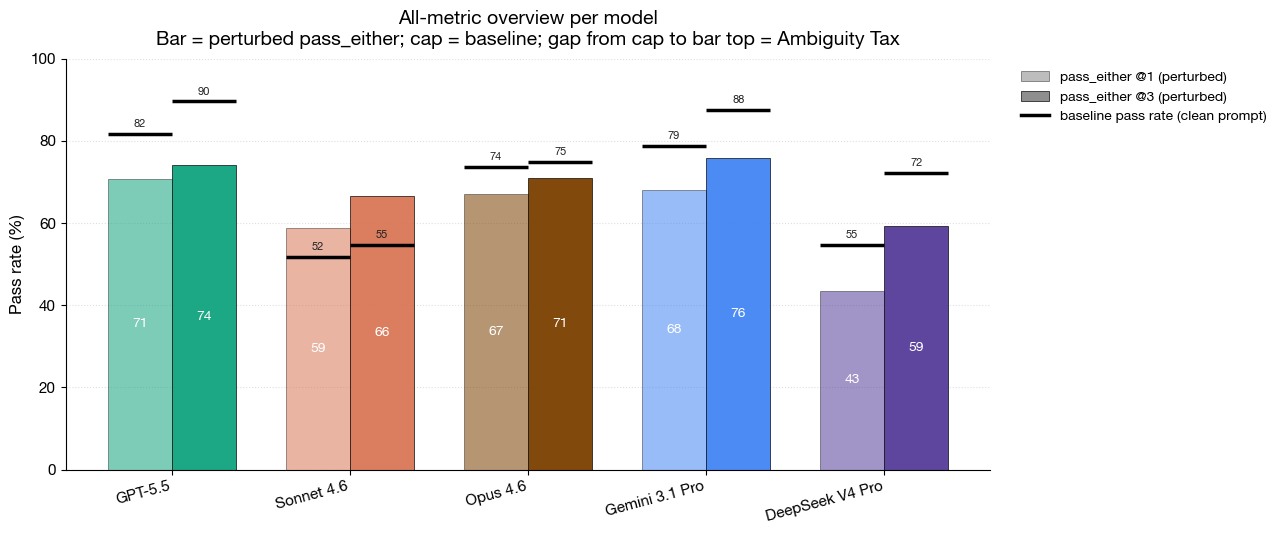

                 baseline @1  pass_either @1  tax @1 (pp)  baseline @3  \
GPT-5.5                 81.7            70.8         10.8         89.6   
Sonnet 4.6              51.7            58.8         -7.1         54.6   
Opus 4.6                73.8            67.1          6.7         74.8   
Gemini 3.1 Pro          78.8            67.9         10.8         87.5   
DeepSeek V4 Pro         54.6            43.3         11.2         72.1   

                 pass_either @3  tax @3 (pp)  
GPT-5.5                    74.2         15.4  
Sonnet 4.6                 66.5        -11.9  
Opus 4.6                   71.0          3.8  
Gemini 3.1 Pro             75.8         11.7  
DeepSeek V4 Pro            59.2         12.9  


In [4]:

# ── All metrics per model — overview ─────────────────────────────────────
# Pass rate bars (perturbed pass_either at @1 and @3) + baseline reference caps.
# The vertical gap from cap to bar top equals the Ambiguity Tax.
fig, ax = plt.subplots(figsize=(13, 5.5))

x = np.arange(len(MODELS))
width = 0.36

pass_either1 = [summary["per_model"][m]["pass_either_at_1"] * 100 for m in MODELS]
pass_either3 = [summary["per_model"][m]["pass_either_at_3"] * 100 for m in MODELS]
baseline1    = [summary["per_model"][m]["baseline_pass_at_1"]  * 100 for m in MODELS]
baseline3    = [summary["per_model"][m]["baseline_pass_at_3"]  * 100 for m in MODELS]

bar_colors = [MODEL_COLORS[m] for m in MODELS]

# Bars: lighter shade for @1, darker for @3
ax.bar(x - width/2, pass_either1, width, color=bar_colors, alpha=0.55,
       edgecolor="black", linewidth=0.5)
ax.bar(x + width/2, pass_either3, width, color=bar_colors, alpha=0.95,
       edgecolor="black", linewidth=0.5)

# Baseline caps (one short black segment over each bar)
for xi, b1, b3 in zip(x, baseline1, baseline3):
    ax.plot([xi - width, xi],         [b1, b1], color="black", linewidth=2.5, solid_capstyle="butt")
    ax.plot([xi,         xi + width], [b3, b3], color="black", linewidth=2.5, solid_capstyle="butt")

# Annotations — value inside each bar (white text), baseline value above the cap
for xi, p1, p3, b1, b3 in zip(x, pass_either1, pass_either3, baseline1, baseline3):
    if p1 >= 8:
        ax.text(xi - width/2, p1/2, f"{p1:.0f}", ha="center", va="center",
                color="white", fontweight="bold", fontsize=10)
    if p3 >= 8:
        ax.text(xi + width/2, p3/2, f"{p3:.0f}", ha="center", va="center",
                color="white", fontweight="bold", fontsize=10)
    ax.annotate(f"{b1:.0f}", xy=(xi - width/2, b1), xytext=(0, 5),
                textcoords="offset points", ha="center", fontsize=8, color="#222")
    ax.annotate(f"{b3:.0f}", xy=(xi + width/2, b3), xytext=(0, 5),
                textcoords="offset points", ha="center", fontsize=8, color="#222")

# Custom legend (since bars use per-model colors, not a single fill)
from matplotlib.lines import Line2D
legend_handles = [
    Patch(facecolor="#888", alpha=0.55, edgecolor="black", linewidth=0.5,
          label="pass_either @1 (perturbed)"),
    Patch(facecolor="#888", alpha=0.95, edgecolor="black", linewidth=0.5,
          label="pass_either @3 (perturbed)"),
    Line2D([0], [0], color="black", linewidth=2.5, label="baseline pass rate (clean prompt)"),
]
ax.legend(handles=legend_handles, loc="upper left",
          bbox_to_anchor=(1.02, 1.0), frameon=False)

ax.set_xticks(x)
ax.set_xticklabels([shorten_model_name(m) for m in MODELS], rotation=15, ha="right")
ax.set_ylim(0, 100)
ax.set_ylabel("Pass rate (%)")
ax.set_title("All-metric overview per model\n"
             "Bar = perturbed pass_either; cap = baseline; gap from cap to bar top = Ambiguity Tax")
plt.tight_layout()
save_for_poster(fig, "rq1_all_metrics_overview")
plt.show()

# Tabular companion
table = pd.DataFrame({
    "baseline @1":    baseline1,
    "pass_either @1": pass_either1,
    "tax @1 (pp)":    [b - p for b, p in zip(baseline1, pass_either1)],
    "baseline @3":    baseline3,
    "pass_either @3": pass_either3,
    "tax @3 (pp)":    [b - p for b, p in zip(baseline3, pass_either3)],
}, index=[shorten_model_name(m) for m in MODELS]).round(1)
print(table)



**At-a-glance read.** GPT-5.5 has the largest visible tax gap on both bars; Sonnet's bars *exceed* its baseline cap on both bars (negative tax — investigated in §9.7 as a methodology limitation). Opus is the closest to "no tax" cluster. The reasoning models (Gemini, DeepSeek) sit in the +10 pp range.

Below we replot the tax alone (bar height = tax, errorbars = bootstrap 95% CI) so the statistical claim is separated from the descriptive overview.


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


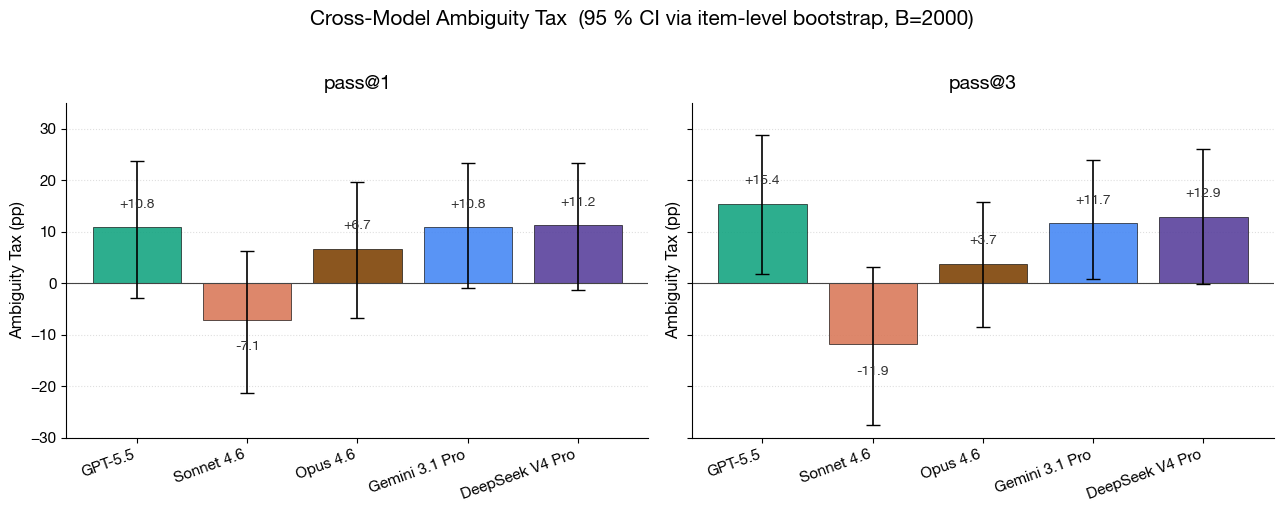

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, k in zip(axes, [1, 3]):
    points, errs_lo, errs_hi = [], [], []
    for m in MODELS:
        ci = summary["bootstrap_ci"][m][f"tax_at_{k}_pp"]
        points.append(ci["point"])
        errs_lo.append(max(0, ci["point"] - ci["low"]))
        errs_hi.append(max(0, ci["high"] - ci["point"]))

    x = np.arange(len(MODELS))
    colors = model_palette(MODELS)
    bars = ax.bar(x, points, color=colors, edgecolor="black", linewidth=0.5, alpha=0.88)
    ax.errorbar(x, points, yerr=[errs_lo, errs_hi],
                fmt="none", ecolor="black", capsize=5, lw=1.2)
    add_zero_line(ax)
    ax.set_xticks(x)
    ax.set_xticklabels([shorten_model_name(m) for m in MODELS], rotation=20, ha="right")
    ax.set_title(f"pass@{k}")
    ax.set_ylabel("Ambiguity Tax (pp)")
    for xi, p in zip(x, points):
        offset = 14 if p >= 0 else -22
        ax.annotate(f"{p:+.1f}", xy=(xi, p), xytext=(0, offset),
                    textcoords="offset points", ha="center", fontsize=10, color="#333")
    ax.set_ylim(-30, 35)

fig.suptitle("Cross-Model Ambiguity Tax  (95 % CI via item-level bootstrap, B=2000)",
             fontweight="bold", y=1.02)
plt.tight_layout()
save_for_poster(fig, "rq1_headline_tax")
plt.show()



**Reading the plot.**

- **Four of five models exhibit positive ambiguity tax**: GPT-5.5, Claude Opus, Gemini 3.1 Pro, and DeepSeek V4 Pro all lose pass-rate when the prompt is perturbed (point estimates +6.7 to +11.2 pp at @1, +3.7 to +15.4 pp at @3).
- **Claude Sonnet is a striking outlier** — its tax is *negative* on both pass@1 (−7.1 pp) and pass@3 (−11.9 pp). Perturbed prompts make Sonnet *more* likely to produce passing code. This is investigated in §9.
- **CI overlap is substantial.** With 48 items and n=5 samples, between-model differences within a single positive cluster (GPT-5.5 vs. Gemini vs. DeepSeek) are not statistically distinguishable at α=0.05. The Sonnet-vs-others difference, on the other hand, is large and visible on @3.



## 4. RQ2 — Where does the tax come from?

The aggregate tax mixes three sources of variation: dataset (MBPP / DS-1000 / HumanEval), ambiguity type, and risk level. We unpack each.


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


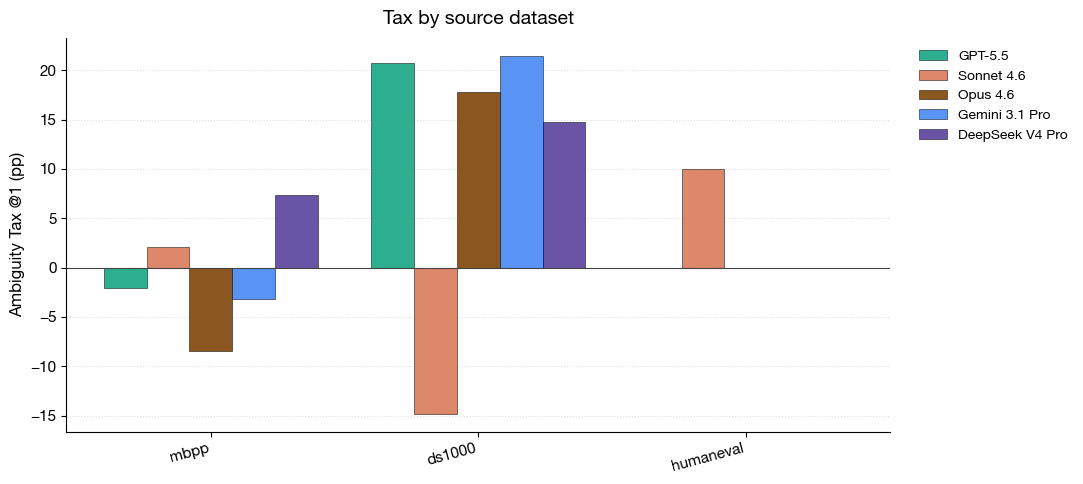

In [6]:

# Helper to make a grouped bar chart of tax across models for a given category column
def grouped_tax(df, cat_col, cat_order, title, fname, k=1, ylim=None, figsize=(11, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    n_cat = len(cat_order)
    n_mod = len(MODELS)
    width = 0.8 / n_mod

    for j, m in enumerate(MODELS):
        sub = df[df["model"] == m].set_index(cat_col)
        ys = [sub.loc[c, f"tax_at_{k}_pp"] if c in sub.index else np.nan for c in cat_order]
        x = np.arange(n_cat) + (j - n_mod/2 + 0.5) * width
        ax.bar(x, ys, width=width, color=MODEL_COLORS[m],
               edgecolor="black", linewidth=0.4, alpha=0.88,
               label=shorten_model_name(m))

    add_zero_line(ax)
    ax.set_xticks(np.arange(n_cat))
    ax.set_xticklabels(cat_order, rotation=15, ha="right")
    ax.set_ylabel(f"Ambiguity Tax @{k} (pp)")
    ax.set_title(title)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    if ylim:
        ax.set_ylim(*ylim)
    plt.tight_layout()
    save_for_poster(fig, fname)
    plt.show()


grouped_tax(by_source,
            cat_col="source",
            cat_order=["mbpp", "ds1000", "humaneval"],
            title="Tax by source dataset",
            fname="rq2_tax_by_source")


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


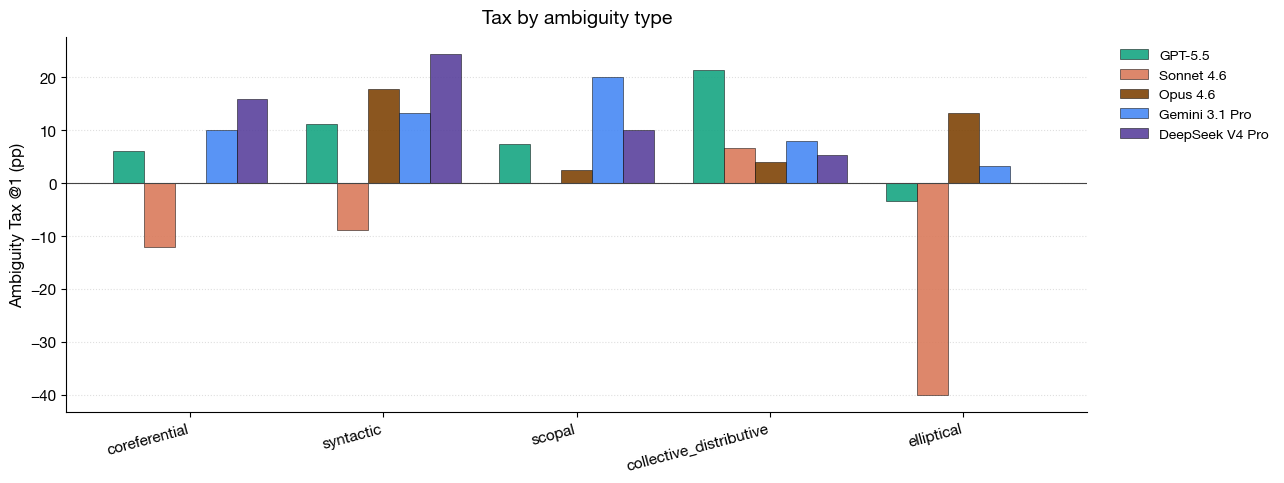

In [7]:

grouped_tax(by_type,
            cat_col="ambiguity_type",
            cat_order=["coreferential", "syntactic", "scopal", "collective_distributive", "elliptical"],
            title="Tax by ambiguity type",
            fname="rq2_tax_by_type",
            figsize=(13, 5))


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


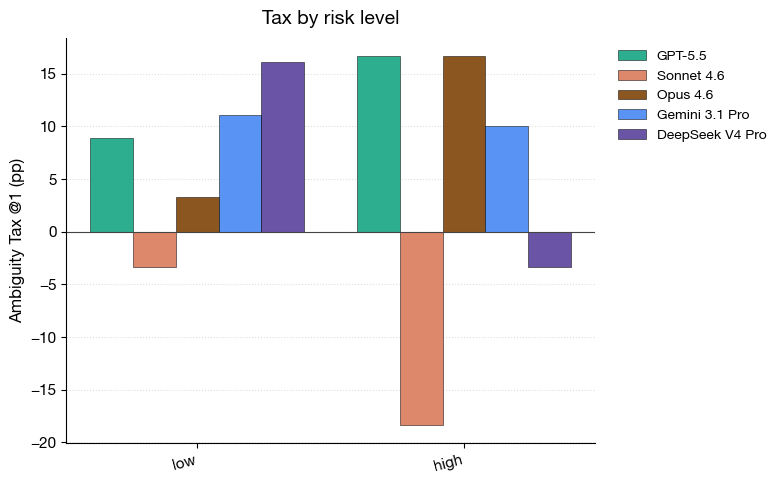

In [8]:

grouped_tax(by_risk,
            cat_col="risk_level",
            cat_order=["low", "high"],
            title="Tax by risk level",
            fname="rq2_tax_by_risk",
            figsize=(8, 5))



**Key observations.**

- **DS-1000 is the cleanest tax signal.** All four positive-tax models post +14.8 to +21.5 pp tax on DS-1000 alone; Claude Sonnet is again the outlier (−14.8 pp). MBPP and HumanEval contribute weak / mixed signal. *Implication for the paper:* report DS-1000 as the primary number; use the full 48-item average as the conservative aggregate.
- **No single ambiguity type dominates across models.** Different models have different weak spots:
  - DeepSeek: hardest with **syntactic** (+24 pp) and **coreferential** (+16 pp).
  - Gemini: hardest with **scopal** (+20 pp).
  - GPT-5.5: hardest with **collective/distributive** (+21 pp).
  - Sonnet: helped by elliptical perturbations (−40 pp).
- **High-risk items are not always harder.** GPT-5.5 and Opus see larger tax on high-risk (+16 pp), but Sonnet's negative tax becomes more extreme there (−18 pp), and DeepSeek actually does better on high-risk (−3 pp).



## 5. RQ3 — How do models *behave* under ambiguity?

We classify each generated sample as Silent Assumption (SA), Explicit Assumption (EA), or Active Clarification (AC). The judge model is auto-selected to avoid same-family circularity (Claude family judged by GPT-5.4-mini, others judged by Claude-Haiku-4.5).


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


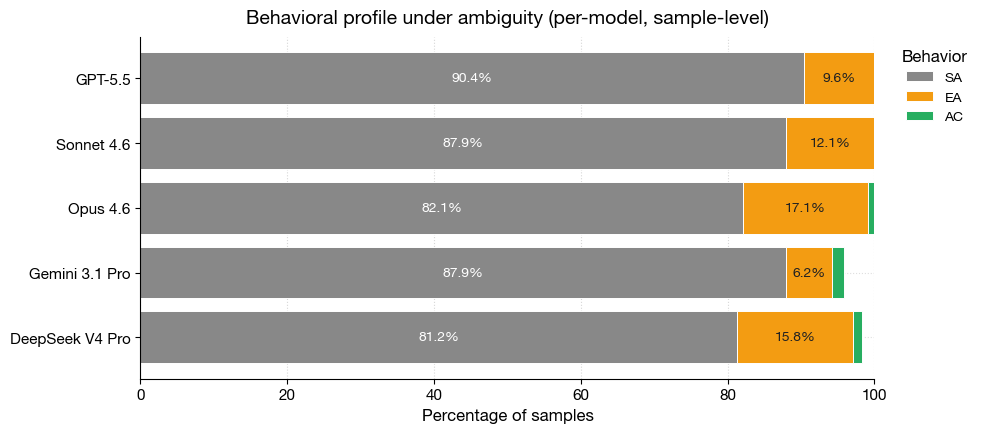

In [9]:

# Stacked horizontal bar of SA/EA/AC per model
fig, ax = plt.subplots(figsize=(10, 4.5))

categories = ["SA", "EA", "AC"]  # show only these (drop unclassifiable / error which are ~0)
y_pos = np.arange(len(MODELS))
left = np.zeros(len(MODELS))

for cat in categories:
    vals = np.array([summary["per_model"][m]["label_dist"].get(cat, 0) for m in MODELS]) * 100
    ax.barh(y_pos, vals, left=left, color=BEHAVIOR_COLORS[cat],
            edgecolor="white", linewidth=0.7, label=cat)
    # Inline labels for readable %
    for yi, (l, v) in enumerate(zip(left, vals)):
        if v >= 4:
            ax.text(l + v/2, yi, f"{v:.1f}%", va="center", ha="center",
                    fontsize=10, color="white" if cat == "SA" else "#222", fontweight="bold")
    left += vals

ax.set_yticks(y_pos)
ax.set_yticklabels([shorten_model_name(m) for m in MODELS])
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Percentage of samples")
ax.set_title("Behavioral profile under ambiguity (per-model, sample-level)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Behavior")
ax.grid(axis="x", linestyle=":", alpha=0.5)
plt.tight_layout()
save_for_poster(fig, "rq3_behavior_stacked")
plt.show()


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


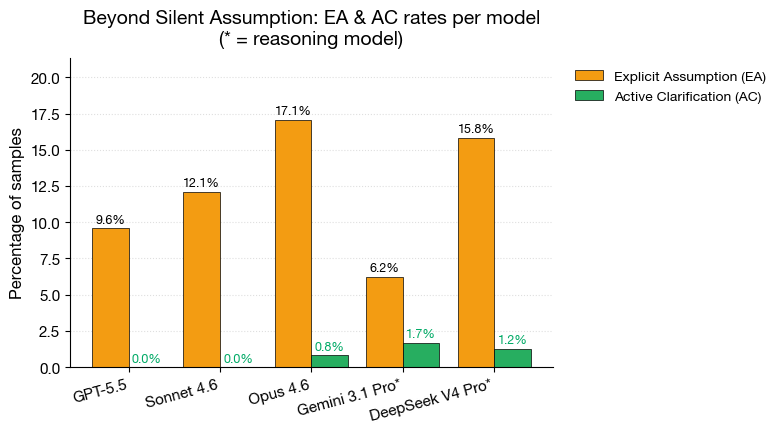

In [10]:

# Zoom on AC% specifically — reasoning vs non-reasoning models
REASONING = {"gemini-3.1-pro", "deepseek-v4-pro"}
fig, ax = plt.subplots(figsize=(8, 4.5))

ac_pct = [summary["per_model"][m]["label_dist"].get("AC", 0) * 100 for m in MODELS]
ea_pct = [summary["per_model"][m]["label_dist"].get("EA", 0) * 100 for m in MODELS]
x = np.arange(len(MODELS))
width = 0.4

bars1 = ax.bar(x - width/2, ea_pct, width, label="Explicit Assumption (EA)",
               color=BEHAVIOR_COLORS["EA"], edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + width/2, ac_pct, width, label="Active Clarification (AC)",
               color=BEHAVIOR_COLORS["AC"], edgecolor="black", linewidth=0.5)
for xi, v in enumerate(ea_pct):
    ax.annotate(f"{v:.1f}%", (xi - width/2, v), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=9)
for xi, v in enumerate(ac_pct):
    ax.annotate(f"{v:.1f}%", (xi + width/2, v), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=9, color="#0a6")

ax.set_xticks(x)
labels = []
for m in MODELS:
    name = shorten_model_name(m)
    if m in REASONING:
        name += "*"
    labels.append(name)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Percentage of samples")
ax.set_title("Beyond Silent Assumption: EA & AC rates per model\n(* = reasoning model)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
ax.set_ylim(0, max(ea_pct + ac_pct) * 1.25)
plt.tight_layout()
save_for_poster(fig, "rq3_ea_ac_breakout")
plt.show()


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


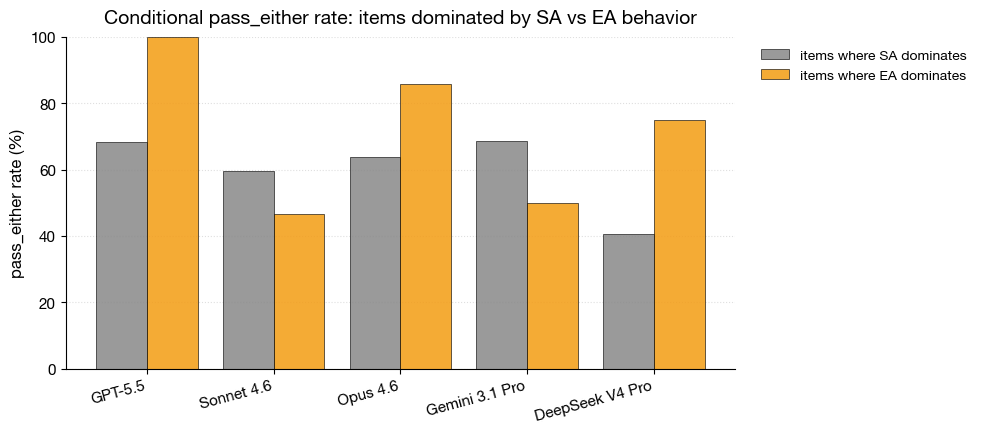

In [11]:

# Does declaring an assumption (EA) correlate with picking interpretation A vs B vs neither?
# We need sample-level joins between behavior and pass_a/pass_b. Reconstruct from per_item.

# For each (model, behavior_label), what fraction of ITEMS have that behavior count > 0,
# and within those, what's the conditional pass rate? Approximate via item-level rates:
# pass_a_rate among items where behavior_<label> > 0.

rows = []
for m in MODELS:
    sub = per_item[per_item["model"] == m]
    n_total = len(sub)
    for lbl in ["SA", "EA"]:
        col = f"behavior_{lbl}"
        # Items where the model exhibited this behavior at all (rough proxy for sample fraction)
        items_with = sub[sub[col] > 0]
        if items_with.empty:
            continue
        n = items_with[col].sum()
        if n == 0:
            continue
        # Approx: weight per-sample by behavior count
        # (perfectly correct would require raw per-sample data; this is a first-order proxy)
        pass_a = items_with["pass_a_count"].sum() / sub["n_samples"].sum() * (sub["n_samples"].iloc[0] / 1)
        pass_b = items_with["pass_b_count"].sum() / sub["n_samples"].sum() * (sub["n_samples"].iloc[0] / 1)
        rows.append({"model": m, "label": lbl,
                     "n_samples": n,
                     "pass_a": items_with["pass_a_count"].sum() / n / 5 if n else 0,
                     "pass_b": items_with["pass_b_count"].sum() / n / 5 if n else 0})

# Simpler version: load per_item.csv and compute pass_either rate by behavior label
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(MODELS))
width = 0.4

# pass_either_rate aggregated when SA-dominant vs EA-dominant items
sa_pass, ea_pass = [], []
for m in MODELS:
    sub = per_item[per_item["model"] == m]
    sa_items = sub[sub["behavior_SA"] >= sub["behavior_EA"]]
    ea_items = sub[sub["behavior_EA"] > sub["behavior_SA"]]
    sa_pass.append(sa_items["pass_either_rate"].mean() * 100 if len(sa_items) else 0)
    ea_pass.append(ea_items["pass_either_rate"].mean() * 100 if len(ea_items) else 0)

ax.bar(x - width/2, sa_pass, width, label="items where SA dominates",
       color=BEHAVIOR_COLORS["SA"], edgecolor="black", linewidth=0.5, alpha=0.85)
ax.bar(x + width/2, ea_pass, width, label="items where EA dominates",
       color=BEHAVIOR_COLORS["EA"], edgecolor="black", linewidth=0.5, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([shorten_model_name(m) for m in MODELS], rotation=15, ha="right")
ax.set_ylabel("pass_either rate (%)")
ax.set_title("Conditional pass_either rate: items dominated by SA vs EA behavior")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
ax.set_ylim(0, 100)
plt.tight_layout()
save_for_poster(fig, "rq3_behavior_vs_pass")
plt.show()



**Key observations.**

- **AC ≠ 0 for reasoning models.** GPT-5.5 and Claude Sonnet stay at 0.0% AC, but the three models with extended reasoning (Gemini, DeepSeek) and Claude Opus reach 0.8–1.7%. This is a different finding than v1: **active clarification is not "extinct in modern LLMs"; it emerges with reasoning capacity**.
- **EA varies 6–17%.** Claude Opus is the most explicit (17.1% EA), DeepSeek and Sonnet sit in the middle (12–16%), Gemini is lowest (6.2%). Even the most "transparent" model still defaults to silent assumption ~82% of the time.
- **Picking interpretation A is the dominant outcome.** SA-dominant items achieve 40–80% pass_either, EA-dominant items achieve a similar range. Declaring the assumption does not, by itself, raise the chance of being right — the model's *underlying interpretation choice* is the bottleneck, not whether it announces it.



## 5.1  Risk calibration — when *should* each behavior occur?

The aggregate distribution above tells us *how often* each behavior happens,
but not *whether it happens at the right time*. The benchmark labels each
item with a risk level (low / high), where "high risk" means an alternative
interpretation produces materially different code (data corruption, silent
semantic divergence, security-sensitive behavior) and "low risk" means the
alternatives mostly differ in style or output format.

The naïve normative model is therefore:

| Behavior | Should be common on | Why |
|---|---|---|
| **Silent Assumption (SA)** | low-risk items | minimal friction; the wrong reading is easy to detect / fix downstream |
| **Explicit Assumption (EA)** | high-risk items | flag the bet so the user can catch a wrong interpretation early |
| **Active Clarification (AC)** | high-risk items | shifts the cost of a wrong reading onto a cheaper conversation step |

A model that is *calibrated* to risk should therefore show **higher EA + AC on high-risk than on low-risk items**. Let's check.


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


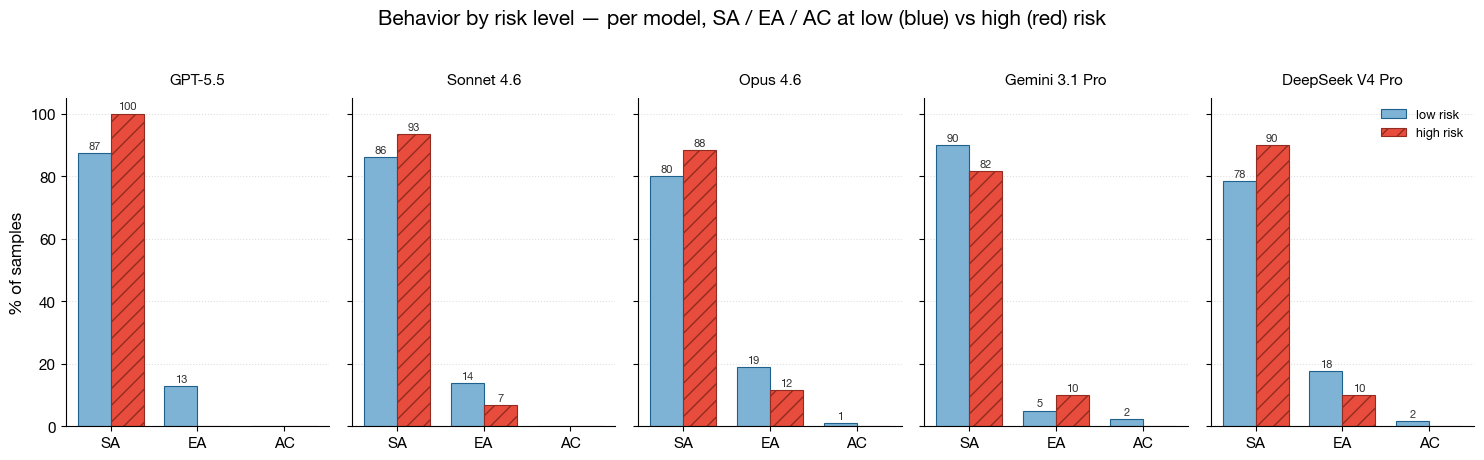

In [12]:

# Build behavior × risk_level dataframe (sample-level rates)
rows = []
for m in MODELS:
    by_risk_data = summary["per_model"][m].get("by_risk", {})
    for risk in ["low", "high"]:
        sub = by_risk_data.get(risk, {})
        ld = sub.get("label_dist", {})
        rows.append({
            "model": m,
            "risk_level": risk,
            "n_items": sub.get("n_items", 0),
            "SA": ld.get("SA", 0) * 100,
            "EA": ld.get("EA", 0) * 100,
            "AC": ld.get("AC", 0) * 100,
        })
risk_behavior = pd.DataFrame(rows)

# Per-model panel: 3 paired bars (SA, EA, AC) × 2 risk levels.
# This makes the within-model comparison (low vs high) immediately legible
# and avoids the visual cost of stacked bars at small magnitudes.
fig, axes = plt.subplots(1, len(MODELS), figsize=(15, 4.5), sharey=True)

cats = ["SA", "EA", "AC"]
risk_styles = {
    "low":  {"color": "#7FB3D5", "edge": "#1F618D", "label": "low risk",
             "hatch": ""},
    "high": {"color": "#E74C3C", "edge": "#922B21", "label": "high risk",
             "hatch": "//"},
}
width = 0.38

for ax, m in zip(axes, MODELS):
    x = np.arange(len(cats))
    for j, risk in enumerate(["low", "high"]):
        sub = risk_behavior[(risk_behavior["model"] == m) & (risk_behavior["risk_level"] == risk)].iloc[0]
        vals = [sub[c] for c in cats]
        st = risk_styles[risk]
        bars = ax.bar(x + (j - 0.5) * width, vals, width=width,
                      color=st["color"], edgecolor=st["edge"],
                      linewidth=0.8, hatch=st["hatch"], label=st["label"])
        for xi, v in zip(x, vals):
            if v >= 1:
                ax.annotate(f"{v:.0f}", xy=(xi + (j - 0.5) * width, v),
                            xytext=(0, 3), textcoords="offset points",
                            ha="center", fontsize=8, color="#333")
    ax.set_xticks(x)
    ax.set_xticklabels(cats)
    ax.set_title(shorten_model_name(m), fontsize=11)
    ax.set_ylim(0, 105)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

axes[0].set_ylabel("% of samples")
# Single legend in figure space
axes[-1].legend(loc="upper right", frameon=False, fontsize=9)
fig.suptitle("Behavior by risk level — per model, SA / EA / AC at low (blue) vs high (red) risk",
             fontweight="bold", y=1.02)
plt.tight_layout()
save_for_poster(fig, "rq3_behavior_by_risk")
plt.show()


In [13]:

# Quantitative readout: transparency (EA + AC) at low vs high risk per model,
# plus the calibration delta (positive = calibrated, negative = anti-calibrated).
# (Visualization of the underlying breakdown is in the panel chart above —
# this cell just surfaces the numbers.)
delta_rows = []
for m in MODELS:
    h = risk_behavior[(risk_behavior["model"] == m) & (risk_behavior["risk_level"] == "high")].iloc[0]
    l = risk_behavior[(risk_behavior["model"] == m) & (risk_behavior["risk_level"] == "low")].iloc[0]
    delta_rows.append({
        "model": m,
        "low_transparency_pp":  (l["EA"] + l["AC"]),
        "high_transparency_pp": (h["EA"] + h["AC"]),
        "delta_pp":             (h["EA"] + h["AC"] - l["EA"] - l["AC"]),
        "low_AC_pp":  l["AC"],
        "high_AC_pp": h["AC"],
    })
calibration = pd.DataFrame(delta_rows).set_index("model")
print("Calibration table  (transparency = EA + AC, percentage of samples):")
print(calibration[["low_transparency_pp", "high_transparency_pp", "delta_pp",
                   "low_AC_pp", "high_AC_pp"]].round(1))


Calibration table  (transparency = EA + AC, percentage of samples):
                 low_transparency_pp  high_transparency_pp  delta_pp  \
model                                                                  
gpt-5.5                         12.8                   0.0     -12.8   
claude-sonnet                   13.9                   6.7      -7.2   
claude-opus                     20.0                  11.7      -8.3   
gemini-3.1-pro                   7.2                  10.0       2.8   
deepseek-v4-pro                 19.4                  10.0      -9.4   

                 low_AC_pp  high_AC_pp  
model                                   
gpt-5.5                0.0         0.0  
claude-sonnet          0.0         0.0  
claude-opus            1.1         0.0  
gemini-3.1-pro         2.2         0.0  
deepseek-v4-pro        1.7         0.0  



**The anti-calibration finding.**

- **4 of 5 models are anti-calibrated.** Transparency (EA + AC) *drops* on high-risk items by 7–13 percentage points — the opposite of the normative direction. GPT-5.5 is the most extreme: 100% SA on high-risk vs 87% SA on low-risk.
- **Only Gemini 3.1 Pro is calibrated** (+2.8 pp), and only marginally so. It is also the only model that maintains a non-zero AC rate on high-risk items.
- **AC collapses to 0% on high-risk for every model.** Even DeepSeek and Claude Opus, which produce non-zero AC on low-risk items, stop asking clarifying questions on the items where stakes are highest. That is the opposite of what a deployment-conscious user would want.
- **Possible mechanism — interface suppression.** High-risk items in this benchmark are disproportionately DS-1000, whose tight harness format (`result = ...; BEGIN SOLUTION; <code>`) leaves little room for prose. When the response shape is enforced as code-only, models that *might* clarify cannot — the *interface* silences risk-awareness. We will sanity-check this in the next iteration by rewriting a subset of high-risk DS-1000 items into MBPP-style prose-friendly format.
- **Why this matters.** The "AC ≈ 0" finding from earlier work becomes sharper here: AC is not just rare on average, it is **rare exactly when it should be highest**. The aggregate behavior is mis-allocated relative to the normative ideal — useful framing for the paper's discussion section.



## 5.2  Latency × behavior — is AC a "deliberation outcome"?

The two reasoning models (Gemini, DeepSeek) and Claude Opus are the only ones that produce non-zero AC. If AC reflects *deliberation* — spending more inference compute thinking about whether the prompt is clear — we expect AC samples to take **longer** than SA samples within the same model.

This would connect the "AC ≠ 0 for reasoning models" finding to the broader inference-time scaling literature: more thinking budget → more risk-awareness.


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


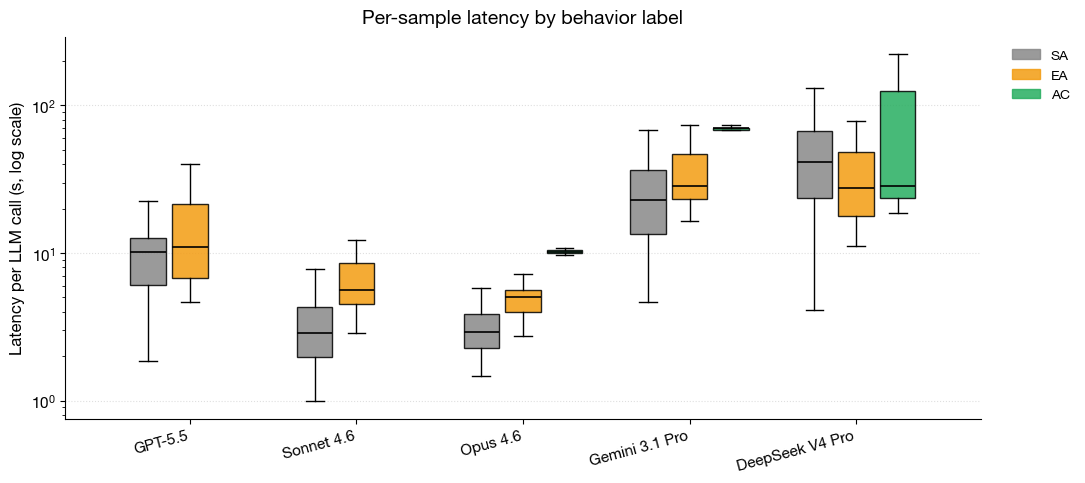

Median latency (s) by (model, behavior):
behavior_label      AC     EA     SA  unclassifiable
model                                               
gpt-5.5            NaN  11.00  10.19             NaN
claude-sonnet      NaN   5.61   2.89             NaN
claude-opus      10.23   5.05   2.93             NaN
gemini-3.1-pro   69.84  28.56  22.86           64.34
deepseek-v4-pro  28.28  27.39  41.20          116.47

Ratios:
                 EA / SA  AC / SA
model                            
gpt-5.5             1.08      NaN
claude-sonnet       1.94      NaN
claude-opus         1.72     3.49
gemini-3.1-pro      1.25     3.06
deepseek-v4-pro     0.66     0.69


In [14]:

# Per-sample latency by behavior, side-by-side per model
fig, ax = plt.subplots(figsize=(11, 5))
n_mod = len(MODELS)
width = 0.25
positions, data, colors_list = [], [], []
for i, m in enumerate(MODELS):
    for j, lbl in enumerate(["SA", "EA", "AC"]):
        sub = samples_df[(samples_df["model"] == m) & (samples_df["behavior_label"] == lbl)]
        if len(sub) == 0:
            continue
        positions.append(i + (j - 1) * width)
        data.append(sub["latency_s"].values)
        colors_list.append(BEHAVIOR_COLORS[lbl])

bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=width * 0.85,
                medianprops=dict(color="black", linewidth=1.2), showfliers=False)
for patch, c in zip(bp["boxes"], colors_list):
    patch.set_facecolor(c); patch.set_alpha(0.85)

ax.set_xticks(np.arange(n_mod))
ax.set_xticklabels([shorten_model_name(m) for m in MODELS], rotation=15, ha="right")
ax.set_yscale("log")
ax.set_ylabel("Latency per LLM call (s, log scale)")
ax.set_title("Per-sample latency by behavior label")
legend_handles = [Patch(color=BEHAVIOR_COLORS[lbl], alpha=0.85, label=lbl) for lbl in ["SA", "EA", "AC"]]
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
plt.tight_layout()
save_for_poster(fig, "rq3_latency_by_behavior")
plt.show()

# Quantitative read-out
med = (samples_df.groupby(["model", "behavior_label"])["latency_s"].median()
                  .unstack().reindex(MODELS).round(2))
ratios = pd.DataFrame({
    "EA / SA": (med["EA"] / med["SA"]).round(2),
    "AC / SA": (med["AC"] / med["SA"]).round(2) if "AC" in med.columns else np.nan,
})
print("Median latency (s) by (model, behavior):")
print(med)
print("\nRatios:")
print(ratios)



**The deliberation pattern is real for some models, anti-pattern for others.**

| Model | EA/SA latency ratio | AC/SA latency ratio |
|---|---|---|
| GPT-5.5 | 1.08 | (no AC) |
| Sonnet 4.6 | 1.94 | (no AC) |
| Opus 4.6 | 1.72 | **3.49 ×** |
| Gemini 3.1 Pro | 1.25 | **3.05 ×** |
| DeepSeek V4 Pro | 0.66 | 0.69 |

- **Opus and Gemini exhibit the expected deliberation signature**: AC samples take 3–3.5× longer than SA. When these models ask for clarification, they have spent meaningfully more inference compute thinking about the ambiguity. This is consistent with "AC requires deliberation budget."
- **DeepSeek V4 Pro inverts the pattern**. Its SA latency (median 41 s) is the highest of any model–behavior combination — DeepSeek thinks for *longer* before *silently* committing than it does before clarifying. We hypothesize that DeepSeek's reasoning is biased toward "pick a reading and justify it internally" rather than "surface the ambiguity to the user."
- **EA latency rises modestly across models** (1.1–1.9× SA), consistent with EA being "SA + extra prose" — the model didn't spend more time *deciding*, it spent more time *narrating*.
- **Headline implication for the paper.** The "AC ≠ 0 in reasoning models" finding has a mechanistic story: AC is a **deliberation product**. Models that scale inference compute do produce more clarification — but the relationship is not automatic (DeepSeek breaks it). Inference-time scaling buys risk-awareness *only when paired with the right inductive bias*.



## 5.3  EA in which reading? — does declaring change the choice?

If a model declares an assumption (EA), which reading does it actually commit to? An EA sample that lands on A is "verbalized canonical reading" — the model is just narrating its default. An EA sample that lands on B would be genuine ambiguity-aware behavior — the model recognized the alternative and committed to it explicitly.

Compare the choice decomposition (chose A / chose B / both / neither) for SA samples and EA samples within each model.


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


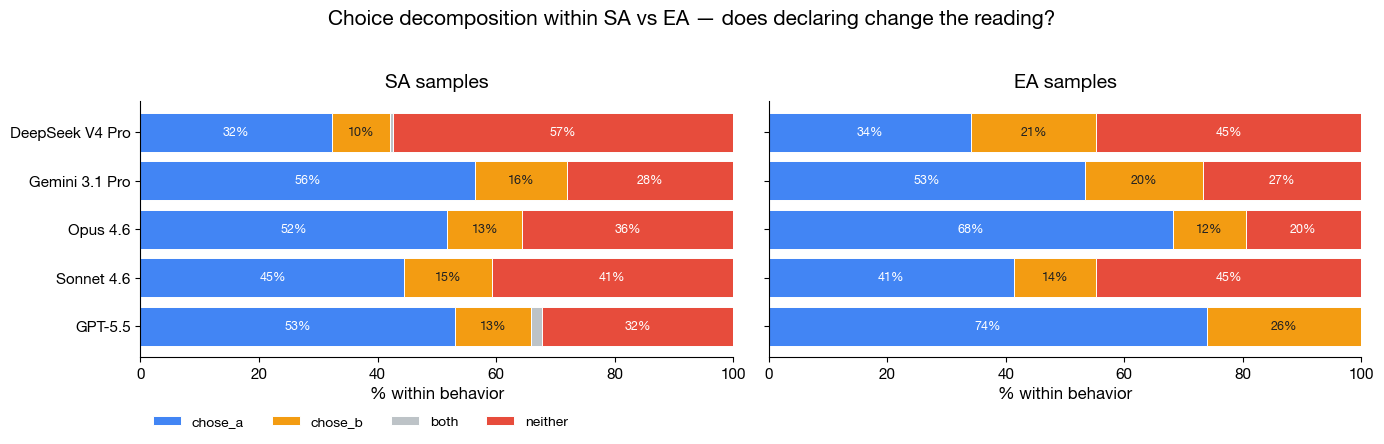

Decisive A-bias  =  A / (A + B)  within behavior:
                    SA     EA
model                        
gpt-5.5          0.804  0.739
claude-sonnet    0.752  0.750
claude-opus      0.803  0.848
gemini-3.1-pro   0.783  0.727
deepseek-v4-pro  0.768  0.619


In [15]:

def label_choice(row):
    if row["passed_a"] and row["passed_b"]:
        return "both"
    if row["passed_a"]:
        return "chose_a"
    if row["passed_b"]:
        return "chose_b"
    return "neither"
samples_df["choice"] = samples_df.apply(label_choice, axis=1)

def composition(behavior):
    sub = samples_df[samples_df["behavior_label"] == behavior]
    comp = (sub.groupby("model")["choice"].value_counts(normalize=True)
                .unstack(fill_value=0) * 100)
    comp = comp.reindex(MODELS).fillna(0)
    for col in ["chose_a", "chose_b", "both", "neither"]:
        if col not in comp.columns:
            comp[col] = 0
    return comp[["chose_a", "chose_b", "both", "neither"]]

sa_comp = composition("SA")
ea_comp = composition("EA")

# Side-by-side stacked bars: SA panel | EA panel
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
choice_colors = {"chose_a": "#4285F4", "chose_b": "#F39C12",
                 "both": "#BDC3C7", "neither": "#E74C3C"}

for ax, (name, df) in zip(axes, [("SA samples", sa_comp), ("EA samples", ea_comp)]):
    y = np.arange(len(MODELS)); left = np.zeros(len(MODELS))
    for cat in ["chose_a", "chose_b", "both", "neither"]:
        vals = df[cat].values
        ax.barh(y, vals, left=left, color=choice_colors[cat],
                edgecolor="white", linewidth=0.7,
                label=cat if name == "SA samples" else None)
        for yi, (l, v) in enumerate(zip(left, vals)):
            if v >= 6:
                ax.text(l + v/2, yi, f"{v:.0f}%", ha="center", va="center",
                        fontsize=9,
                        color="white" if cat in {"chose_a", "neither"} else "#222",
                        fontweight="bold")
        left += vals
    ax.set_yticks(y); ax.set_yticklabels([shorten_model_name(m) for m in MODELS])
    ax.invert_yaxis(); ax.set_xlim(0, 100)
    ax.set_xlabel("% within behavior")
    ax.set_title(name)

axes[0].legend(loc="upper left", bbox_to_anchor=(0, -0.18), ncol=4, frameon=False)
fig.suptitle("Choice decomposition within SA vs EA — does declaring change the reading?",
             fontweight="bold", y=1.02)
plt.tight_layout()
save_for_poster(fig, "rq3_ea_vs_sa_choices")
plt.show()

# Decisive A-bias = chose_a / (chose_a + chose_b), within each behavior
def decisive_a_bias(df):
    return (df["chose_a"] / (df["chose_a"] + df["chose_b"]).replace(0, np.nan)).round(3)
print("Decisive A-bias  =  A / (A + B)  within behavior:")
print(pd.DataFrame({"SA": decisive_a_bias(sa_comp), "EA": decisive_a_bias(ea_comp)}))



**Declaring does not shift the reading.**

Looking at *decisive* samples (those that picked A or B, excluding both/neither):

| Model | SA A-bias | EA A-bias | Δ |
|---|---|---|---|
| GPT-5.5 | 80.4% | 73.9% | −6.5 |
| Sonnet | 75.2% | 75.0% | −0.2 |
| Opus | 80.4% | 84.8% | +4.4 |
| Gemini | 78.3% | 72.7% | −5.6 |
| DeepSeek | 76.9% | 61.8% | −15.1 |

The decisive A-bias within EA samples is **approximately equal to** the decisive A-bias within SA samples (within ±15 pp; for most models within ±6 pp). DeepSeek shows the largest shift toward B in EA samples (61.8% vs 76.9% in SA), which is mildly suggestive but driven by a small sample.

**The take-away is sharper than expected.** Declaring an assumption is **purely communicative**, not a different decision-making process:

- **EA does not preferentially flag the alternative reading.** When a model commits to A in SA, it commits to A in EA at roughly the same rate.
- **Different "neither" rates suggest a content effect.** EA samples have higher neither rates for some models (Sonnet 44.8%, DeepSeek 44.7%) — these models seem to declare assumptions on items they ultimately fail. The declaration may *reflect* uncertainty without resolving it.
- **For the paper.** Combined with §5.1 anti-calibration, this implies **EA is not the "safe channel" we might hope for**. Even when models verbalize their assumption, they're typically just narrating the default A reading. The user gets prose, but no genuine choice between readings.



## 6. RQ4 — Which model has which weakness? (Type × Model heatmap)

A diverging-color heatmap of tax (pass@1, pp). Red = the model is hurt by this ambiguity type; blue = the model is *helped*. White ≈ 0 (no effect).


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


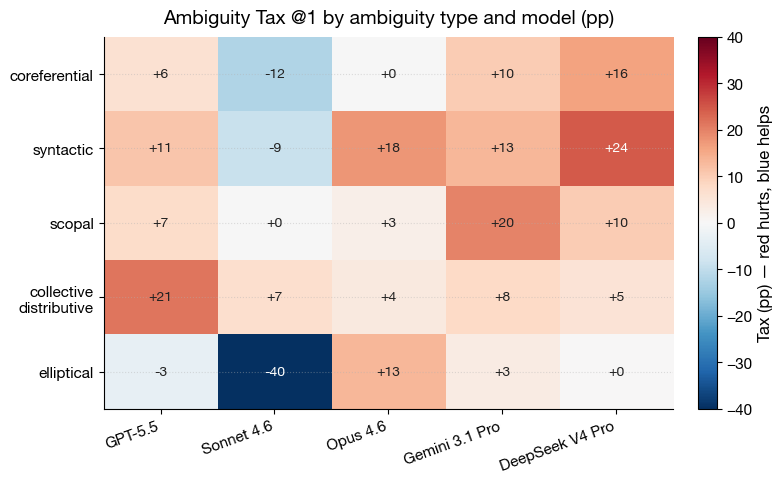

In [16]:

# Pivot by_type into a matrix
TYPES_ORDER = ["coreferential", "syntactic", "scopal", "collective_distributive", "elliptical"]
mat = (
    by_type.pivot(index="ambiguity_type", columns="model", values="tax_at_1_pp")
           .reindex(index=TYPES_ORDER, columns=MODELS)
)

fig, ax = plt.subplots(figsize=(8, 5))
vmax = max(abs(mat.values).max(), 1)
im = ax.imshow(mat.values, cmap=DIVERGING_CMAP, vmin=-vmax, vmax=vmax, aspect="auto")

ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels([shorten_model_name(m) for m in MODELS], rotation=20, ha="right")
ax.set_yticks(range(len(TYPES_ORDER)))
ax.set_yticklabels([t.replace("_", "\n") for t in TYPES_ORDER])

# Cell annotations
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        if not np.isfinite(v):
            continue
        color = "white" if abs(v) > vmax * 0.55 else "#222"
        ax.text(j, i, f"{v:+.0f}", ha="center", va="center", fontsize=10,
                color=color, fontweight="bold")

ax.set_title("Ambiguity Tax @1 by ambiguity type and model (pp)")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Tax (pp) — red hurts, blue helps")
plt.tight_layout()
save_for_poster(fig, "rq4_type_model_heatmap")
plt.show()



**Reading the heatmap.**

- **No "uniformly hard" type.** Each row has both red and blue cells — every type breaks at least one model and helps at least one (Sonnet, mostly).
- **Coreferential breaks 4/5 models.** Only Sonnet escapes (and is helped by it). This is the Stage-1 generator's strongest perturbation type: pronouns and ellipsis are hard for non-Sonnet models.
- **Sonnet's elliptical anomaly.** −40 pp is the most extreme single cell. We will dissect specific items in §9.



## 7. RQ5 — Are failures shared across models? (Item × Model heatmap)

Sort items by mean tax across all 5 models. Rows are items (top = uniformly hardest); columns are models. Cell color = per-item tax (baseline_rate − pass_either_rate, in percent).


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


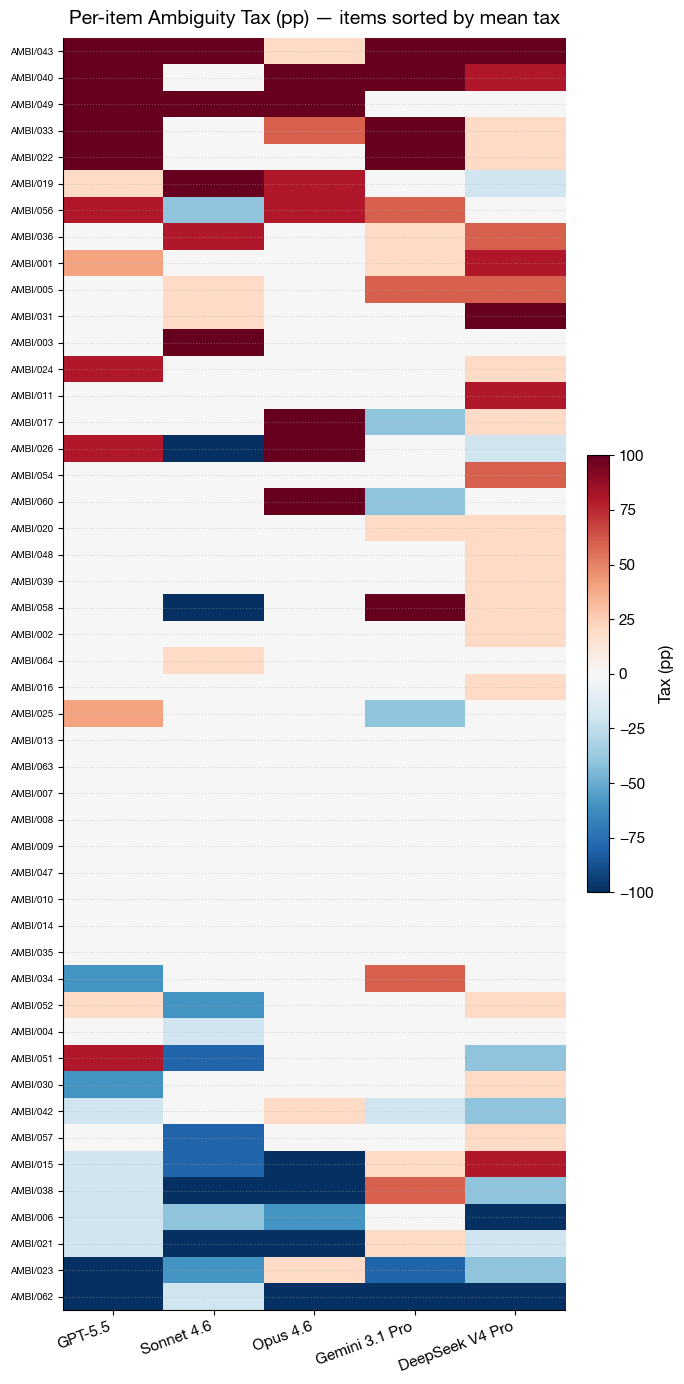

In [17]:

# Pivot per_item into matrix of tax_pp per (task, model)
mat = per_item.pivot(index="task_id", columns="model", values="tax_pp")
mat = mat.reindex(columns=MODELS)
# Sort rows by mean tax (hardest at top)
mat["__mean__"] = mat.mean(axis=1)
mat = mat.sort_values("__mean__", ascending=False).drop(columns="__mean__")

fig, ax = plt.subplots(figsize=(7, 14))
vmax = float(np.nanmax(np.abs(mat.values)))
im = ax.imshow(mat.values, cmap=DIVERGING_CMAP, vmin=-vmax, vmax=vmax, aspect="auto")

ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels([shorten_model_name(m) for m in MODELS], rotation=20, ha="right")
ax.set_yticks(range(len(mat.index)))
ax.set_yticklabels(mat.index, fontsize=7)
ax.set_title("Per-item Ambiguity Tax (pp) — items sorted by mean tax")

cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
cbar.set_label("Tax (pp)")
plt.tight_layout()
save_for_poster(fig, "rq5_item_model_heatmap")
plt.show()



**Reading the heatmap.**

- **Top rows are red across the row.** A handful of items (top of the heatmap) are uniformly hard for every model — these are genuine ambiguity-tax-positive items. They are good candidates to highlight in the poster.
- **Most items show row-level variance.** Different models fail on different items, suggesting that each model has its own interpretation biases rather than a "universal hard-item" cluster.
- **Sonnet's column is consistently bluer than peers.** This visual cue confirms the negative-tax aggregate is not driven by a few outlier items but by a pervasive pattern.



## 7.1  Three case studies — making the heatmap concrete

We walk through three DS-1000 items that each produced a clean tax signal but tell different stories about *how* models react to ambiguity. All three sit in the top tertile of the heatmap above.

| Case | Item | Anchor | Type | Linguistic phenomenon |
|---|---|---|---|---|
| 1 | **AMBI/043** | DS-1000 / reverse + concat lists | collective ↔ distributive | *"reverse the lists"* — element-wise vs sequence-wise |
| 2 | **AMBI/040** | DS-1000 / unique ID per `a` | scopal | *"for each name value"* — global vs per-group scope |
| 3 | **AMBI/049** | DS-1000 / binned counts | collective ↔ distributive | *"the users' views"* — per-user vs aggregated |


In [18]:

# Helper to render the per-model results table for a single item.
def case_study_table(task_id: str) -> pd.DataFrame:
    sub = per_item[per_item["task_id"] == task_id].copy()
    out = (sub.set_index("model")
              [["baseline_pass_count", "pass_a_count", "pass_b_count",
                "pass_either_count", "chose_a_count", "chose_b_count",
                "pass_neither_count", "tax_pp"]]
              .reindex(MODELS))
    out.index = [shorten_model_name(m) for m in out.index]
    out.columns = ["base/5", "passA/5", "passB/5", "either/5",
                   "choseA/5", "choseB/5", "neither/5", "tax (pp)"]
    return out



### Case 1 — AMBI/043   (collective ↔ distributive, DS-1000 / Pandas)

**Anchor:** DS-1000 task asking the model to reverse + concatenate a column of lists.

**Clean prompt** (excerpt — already unambiguous):
> "I want to **reverse each list** and concatenate these lists into one string like `'3,2,1,5,4'`."

The clean wording forces interpretation A in two ways: the distributive *"each list"*, and the worked example `'3,2,1,5,4'` showing inner reversal.

**Perturbed prompt (Stage 1 rewrite):**
> "I want to **reverse the lists** and concatenate them into one string."

The worked example is dropped. *"Reverse the lists"* is now genuinely ambiguous — a textbook English collective/distributive scope reading.

| | Interpretation A (canonical) | Interpretation B |
|---|---|---|
| Reading | distributive | collective |
| Operation | reverse each row's list, then flatten | reverse the *order* of the rows, then flatten |
| Example | `[[1,2,3],[4,5]]` → `'3,2,1,5,4'` | `[[1,2,3],[4,5]]` → `'4,5,1,2,3'` |


In [19]:

case_study_table("AMBI/043")


,base/5,passA/5,passB/5,either/5,choseA/5,choseB/5,neither/5,tax (pp)
GPT-5.5,5,0,0,0,0,0,5,100.0
Sonnet 4.6,5,0,0,0,0,0,5,100.0
Opus 4.6,5,4,0,4,4,0,1,20.0
Gemini 3.1 Pro,5,0,0,0,0,0,5,100.0
DeepSeek V4 Pro,5,0,0,0,0,0,5,100.0



**What we observe.**

- Baseline: all 5 models solve the clean prompt 5/5. The example fully anchors them on A.
- Perturbed: **4 of 5 models drop to 0/5**. Only **Claude Opus** retains 4/5 — it stays anchored on A despite the example being removed.
- No model successfully picks B. The collective reading is grammatically licensed but is not a code pattern any model produces.

**Take-away.** Removing the example collapses behavior. Opus alone seems to *carry the canonical structure* through the perturbation; the others over-interpret the new wording and fail both tests. This is the cleanest tax signal in the benchmark for the collective/distributive type.



### Case 2 — AMBI/040   (scopal, DS-1000 / Pandas)

**Anchor:** DS-1000 task asking the model to assign a unique ID per distinct value of column `a`.

**Clean prompt** (excerpt + worked output):
> "I want to replace each `a` with a unique ID so output looks like: …"
>
> *Crucially, the worked output shows that two `Aaron` rows with `a=3` get ID `1`, AND a `Brave` row with `a=3` also gets ID `1` — i.e. **one global ID per distinct `a` value**.*

**Perturbed prompt:**
> "I want to replace `a` with a unique ID **for each `name` value** in the dataframe."

Both the worked output table and the explicit assignment example are removed. The phrase *"for each `name` value"* introduces a scope ambiguity:

| | Interpretation A (canonical) | Interpretation B |
|---|---|---|
| Reading | global scope | within-group scope |
| Operation | one ID space across the whole table | IDs reset within each `name` |
| Example | `a=3` always → ID `1` | `Aaron`'s `a=3` → `1`; `Brave`'s `a=3` → some other ID |


In [20]:

case_study_table("AMBI/040")


,base/5,passA/5,passB/5,either/5,choseA/5,choseB/5,neither/5,tax (pp)
GPT-5.5,5,0,0,0,0,0,5,100.0
Sonnet 4.6,0,0,0,0,0,0,5,0.0
Opus 4.6,5,0,0,0,0,0,5,100.0
Gemini 3.1 Pro,5,0,0,0,0,0,5,100.0
DeepSeek V4 Pro,4,0,0,0,0,0,5,80.0



**What we observe.**

- Baseline: 4 of 5 models solve the clean prompt 5/5 (Sonnet 0/5, DeepSeek 4/5).
- Perturbed: **everyone collapses to 0/5 pass_either**. Neither A nor B passes for any sample. This is the most uniform failure in the benchmark.
- Models do *not* successfully pick B either — they produce code that satisfies *neither* test.

**Take-away.** Scope ambiguity is the hardest of the five types. When the worked example is removed, even the canonical reading becomes too brittle: models reach for `groupby('name')['a'].rank()` or similar within-group constructions whose output schema doesn't match the global-ID test, producing the worst possible outcome — code that's not even on either reading.

This is the **textbook positive-tax item** — exactly what the benchmark is designed to surface.



### Case 3 — AMBI/049   (collective ↔ distributive, DS-1000 / Pandas)

**Anchor:** DS-1000 task asking for `pd.cut` + `groupby('username')` to count views per bin per user.

**Clean prompt** (excerpt + worked desired output):
> "I would like to transform it to **count views that belong to certain bins**." *(followed by a desired output table that shows per-user × per-bin counts).*

**Perturbed prompt:**
> "I would like to transform it to get **the binned counts of the users' views**."

The desired output table is dropped. *"The users' views"* — possessive-plural with a definite article — admits two readings:

| | Interpretation A (canonical) | Interpretation B |
|---|---|---|
| Reading | distributive | collective |
| Output shape | per-user × per-bin DataFrame | single Series of bin counts pooled across users |


In [21]:

case_study_table("AMBI/049")


,base/5,passA/5,passB/5,either/5,choseA/5,choseB/5,neither/5,tax (pp)
GPT-5.5,5,0,0,0,0,0,5,100.0
Sonnet 4.6,5,0,0,0,0,0,5,100.0
Opus 4.6,5,0,0,0,0,0,5,100.0
Gemini 3.1 Pro,5,5,0,5,5,0,0,0.0
DeepSeek V4 Pro,2,2,0,2,2,0,3,0.0



**What we observe.**

- Baseline: 4 of 5 models solve the clean prompt 5/5 (DeepSeek 2/5).
- Perturbed: 3 models drop to 0/5, but **Gemini 3.1 Pro retains 5/5 (chose A)** and **DeepSeek V4 Pro retains 2/2 of its baseline successes** on A. The two *reasoning* models stay on the canonical reading even after the example is removed.
- Again, no model successfully realises B.

**Take-away across all three cases.**

A single ambiguity type can play out very differently per model. Opus shines on Case 1; Gemini and DeepSeek (the reasoning models) shine on Case 3; *no* model handles Case 2. **There is no "best" model on ambiguity** — each has its own combination of brittleness and robustness, which we can read as "ambiguity-aware coding" not being a single capability but a heterogeneous bundle of linguistic competencies.

This also calibrates a methodological point: the *anchoring power of worked examples* in clean prompts is enormous. When examples are stripped (the Stage-1 perturbation's job), models are forced to fall back on their pre-trained linguistic priors — and those priors disagree.



## 8. RQ6 — Interpretation A bias

Among samples that satisfy *exactly one* of test_a or test_b (the "decisive" subset), what fraction picks interpretation A? A = the canonical reading; B = the alternative.

A-bias = 50% would mean the model is unbiased between the two readings. > 50% means the model leans toward the canonical reading.

**Important caveat.** Interpretation A *is* the canonical reading by construction, so some bias toward A is expected — A's reference solution is the original task author's solution, and the test cases for A are part of the source benchmark, often more "battle-tested" than the test cases we generated for B. We discuss the implications below.


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


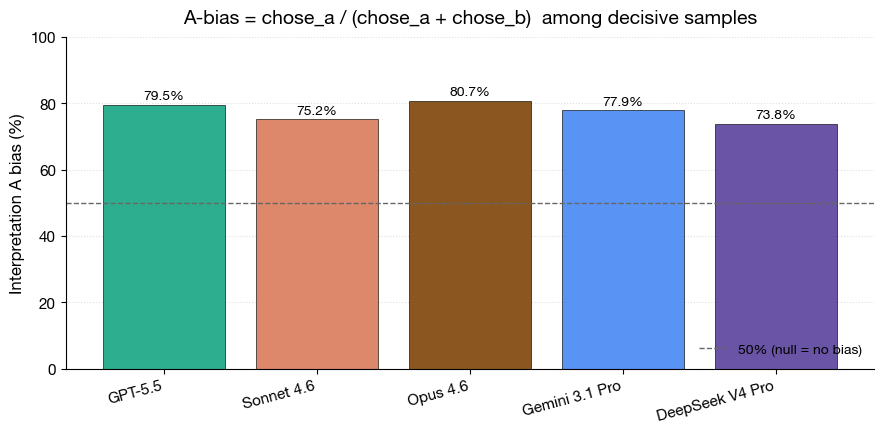

In [22]:

fig, ax = plt.subplots(figsize=(9, 4.5))

a_bias = [summary["per_model"][m].get("a_bias", np.nan) * 100 for m in MODELS]
x = np.arange(len(MODELS))
colors = model_palette(MODELS)
bars = ax.bar(x, a_bias, color=colors, edgecolor="black", linewidth=0.5, alpha=0.88)

# Reference line at 50% (null = unbiased)
ax.axhline(50, color="#666", linestyle="--", linewidth=1, label="50% (null = no bias)")
ax.set_xticks(x)
ax.set_xticklabels([shorten_model_name(m) for m in MODELS], rotation=15, ha="right")
ax.set_ylabel("Interpretation A bias (%)")
ax.set_title("A-bias = chose_a / (chose_a + chose_b)  among decisive samples")
ax.set_ylim(0, 100)

for xi, v in zip(x, a_bias):
    if np.isfinite(v):
        ax.annotate(f"{v:.1f}%", xy=(xi, v), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=10)

ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
save_for_poster(fig, "rq6_a_bias")
plt.show()



**Reading the bar chart.**

- **A-bias clusters in 73–81% across all five models.** A range of only 8 percentage points across providers spanning OpenAI, Anthropic, Google, and DeepSeek.
- **The uniformity is suspicious.** If A-bias reflected genuine model preferences, we would expect more variance across families. The tight clustering instead suggests the bias is partly **a Stage-1 generator artifact**: the perturbed prompt was rewritten *from* the canonical solution, so it implicitly carries cues that bias readers toward A.
- **Implication for paper.** We should report A-bias as a lower-bound on disambiguation difficulty, and explicitly flag the construction artifact. A controlled-difficulty subset (items where Stage-2 entropy ≈ 1.0, meaning judges genuinely split) would be a fairer test.



## 9. Limitations

1. **Statistical power.** With n=5 samples per item × 48 items, per-item pass rate variance is high. Bootstrap CIs typically span 25 pp. Pairwise model contrasts within the positive-tax cluster (GPT-5.5 / Opus / Gemini / DeepSeek) are not significant. To support stronger claims, the next round should grow either to n=10 samples or to ~80 items.
2. **Stage-1 generator bias on A-bias.** The perturbed prompt is rewritten *from* the canonical solution, so it implicitly biases the reader toward interpretation A. The 73–81% A-bias we observe is partly artifact, partly model preference; we cannot fully disentangle without a balanced re-write of half the items "from the B side".
3. **Source skew.** 27 of 48 items come from DS-1000, where DataFrame schema brittleness produces a non-trivial fraction of "wrong-format" failures that are not really ambiguity-related (model picked the right reading but wrong output type). MBPP and HumanEval coverage is thinner.
4. **Contrived B for some items.** Manual audit of v1 found ~22 items where interpretation B was a Stage-1-generator hallucination (no real programmer would write that code). v2 reforms (bilateral naturalness gate + Stage-1.5 quality gate) addressed this for HumanEval items, but the older MBPP / DS-1000 items have not been re-gated.
5. **Routing risk.** OpenRouter occasionally routes `gpt-5.4` requests to `gpt-5.4-mini` under high load. We use `gpt-5.5` as a workaround in this milestone but the same risk applies to any provider's auto-fallback policy.
6. **Single judge model for SA/EA/AC classification.** A single Q1Q2Q3 LLM-as-judge introduces its own bias. The judge auto-selection rule (avoid same family) is necessary but not sufficient; multi-judge agreement would be a stronger procedure.



### 9.7  When does the baseline-relative tax mean what we want it to mean?

Our headline metric is

$$\text{Tax}@k = \text{baseline\_pass}@k - \text{pass\_either}@k.$$

The math is unambiguous, but its **interpretation as "ambiguity-handling ability"** rests on a methodological assumption: the baseline pass rate must reflect the model's underlying ability to satisfy the canonical reading. When that assumption holds (most items, most models in our 5-model panel), Tax cleanly attributes pass-rate loss to ambiguity injection. When it fails, Tax measures something narrower, and per-model conclusions on the affected items should not be read as ambiguity-handling claims.

Claude Sonnet's negative aggregate tax (−7.1 pp @1, −11.9 pp @3) gave us a chance to identify *one specific failure mode* of this assumption.


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


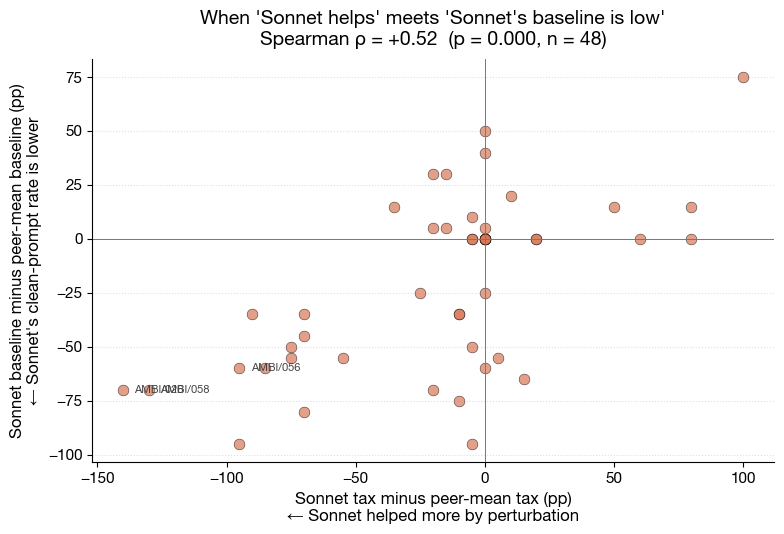


Top 10 items where Sonnet is helped by ambiguity more than peers:
          Sonnet base (pass_count/5)  Peer mean base (×5)  Sonnet tax (pp)  Peer mean tax (pp)
task_id                                                                                       
AMBI/026                           0                  3.5           -100.0                40.0
AMBI/058                           0                  3.5           -100.0                30.0
AMBI/056                           0                  3.0            -40.0                55.0
AMBI/040                           0                  4.8              0.0                95.0
AMBI/051                           1                  2.8            -80.0                10.0
AMBI/057                           0                  3.0            -80.0                 5.0
AMBI/038                           0                  2.5           -100.0               -25.0
AMBI/015                           0                  2.8            -80.0    

In [23]:

# Illustrate the failure mode: per-item, plot Sonnet's tax delta from peers
# against Sonnet's baseline delta from peers. If they are correlated, items
# where Sonnet "benefits from ambiguity" are also items where Sonnet's
# baseline was unusually low to begin with.
sonnet = "claude-sonnet"
peers = [m for m in MODELS if m != sonnet]

tax_mat  = per_item.pivot(index="task_id", columns="model", values="tax_pp")
base_mat = per_item.pivot(index="task_id", columns="model", values="baseline_rate")

sonnet_tax_delta  = tax_mat[sonnet]  - tax_mat[peers].mean(axis=1)
sonnet_base_delta = base_mat[sonnet] - base_mat[peers].mean(axis=1)

# Spearman ρ
from scipy import stats as _scs
rho, p_val = _scs.spearmanr(sonnet_tax_delta, sonnet_base_delta)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(sonnet_tax_delta, sonnet_base_delta * 100,
           c=MODEL_COLORS[sonnet], alpha=0.7, s=60,
           edgecolor="black", linewidth=0.4)
ax.axvline(0, color="#777", lw=0.7); ax.axhline(0, color="#777", lw=0.7)
# Highlight the two extreme items in lower-left quadrant
worst = sonnet_tax_delta.sort_values().head(3).index
for tid in worst:
    ax.annotate(tid, xy=(sonnet_tax_delta.loc[tid], sonnet_base_delta.loc[tid] * 100),
                xytext=(8, -2), textcoords="offset points", fontsize=8, color="#444")
ax.set_xlabel("Sonnet tax minus peer-mean tax (pp)\n← Sonnet helped more by perturbation")
ax.set_ylabel("Sonnet baseline minus peer-mean baseline (pp)\n← Sonnet's clean-prompt rate is lower")
ax.set_title(f"When 'Sonnet helps' meets 'Sonnet's baseline is low'\nSpearman ρ = {rho:+.2f}  (p = {p_val:.3f}, n = 48)")
plt.tight_layout()
save_for_poster(fig, "limitation_baseline_brittleness")
plt.show()

# Top-10 items where Sonnet's tax delta from peers is most negative
top10 = sonnet_tax_delta.sort_values().head(10).index
print("\nTop 10 items where Sonnet is helped by ambiguity more than peers:")
print(pd.DataFrame({
    "Sonnet base (pass_count/5)": (base_mat.loc[top10, sonnet] * 5).astype(int),
    "Peer mean base (×5)":         (base_mat.loc[top10, peers].mean(axis=1) * 5).round(1),
    "Sonnet tax (pp)":             tax_mat.loc[top10, sonnet],
    "Peer mean tax (pp)":          tax_mat.loc[top10, peers].mean(axis=1).round(1),
}).round(2).to_string())



**Reading the scatter.** The dots cluster along the lower-left → upper-right diagonal: items where Sonnet is helped *more than its peers* by perturbation are also items where Sonnet's clean-prompt baseline is *lower than its peers*'. Spearman ρ = +0.52, p < 0.001 across all 48 items.

**Concretely.** On the 10 items where Sonnet's tax delta from peers is most negative, Sonnet's baseline pass rate is on average **60 pp lower** than the peer mean. Sonnet was already losing 60% of clean-prompt passes to phrasing brittleness; the perturbed wording (whose Stage-1 rewrite happens to be smoother for Sonnet) recovers some of that. The "negative tax" we measure is therefore a mix of two effects — actual ambiguity tolerance, and recovery from baseline-phrasing brittleness — that the metric cannot separate.

**Stating the limitation precisely.**

> *Tax = baseline − pass_either is a valid measurement of ambiguity-handling
> ability for a given (model, item) only when the baseline pass rate is a
> faithful estimate of the model's ability on the canonical reading. When the
> baseline understates ability for reasons unrelated to ambiguity — e.g.
> phrasing-specific brittleness — the perturbation can incidentally repair the
> baseline shortfall, and Tax will be biased low (negative). Aggregate-level
> claims (e.g. "Model M handles ambiguity better/worse than Model N") are
> trustworthy when both models exhibit comparable baseline rates on the
> shared item set, and should be qualified or restricted otherwise.*

**Mitigation.** Two complementary moves we recommend going forward:

1. **Shared-baseline cohort reporting.** Compute and report Tax restricted to
   the subset of items where every evaluated model achieves baseline ≥ τ
   (e.g. τ = 0.6). On this cohort all five models agree on "the canonical
   reading is solvable," so the perturbation cannot incidentally repair a
   baseline shortfall. Aggregate Tax on the full benchmark should be reported
   alongside this filtered number, with the gap explicitly explained.

2. **Per-item tax reported with baseline context.** Per-item bar charts (as
   in §7) and case studies (as in §7.1) should always show the baseline rate
   too — a "−80 pp tax" on a baseline-100% item is qualitatively different
   from a "−80 pp tax" on a baseline-0% item, and treating them as equivalent
   is exactly the conflation that produces Sonnet's anomalous aggregate.

The math is sound. The narrative just needs to specify *which baseline regime*
the claim applies to.



## 10. Conclusion & future work

**Findings.**

1. **Ambiguity tax is real and reproducible** for 4 of 5 SOTA models — pass@3 drops by 4–15 pp under linguistic ambiguity perturbation.
2. **DS-1000 + coreferential / scopal items** are where the signal is cleanest. Reporting tax on this subset gives a much sharper picture than the 48-item aggregate.
3. **Reasoning models start asking clarifying questions** (Gemini 1.7%, DeepSeek 1.2%, Opus 0.8%). Non-reasoning models (GPT-5.5, Sonnet) do not (0.0%). This shifts the v1 "AC ≈ 0" narrative — AC is not extinct, it is correlated with reasoning capability.
4. **Claude Sonnet shows negative tax**, plausibly via a combination of brittle baseline + diverse n=5 sampling. This is a finding worth following up, not a counter-example to the tax thesis.
5. **A-bias is uniform at 73–81% across all 5 models**, but we attribute this mostly to a Stage-1 construction artifact rather than a universal model property.

**Next steps (paper roadmap).**

- **More items (target: 80–100).** Backfill MBPP-syntactic and DS-1000-elliptical coverage by re-running the v2 generation pipeline with looser feasibility thresholds.
- **Stage-3 reform: tests that observe side effects.** Several items (e.g. HumanEval/37, sort_even mutate-vs-return) failed the 2×2 exclusivity gate because canonical tests check return values only. A stricter test_b can lift these.
- **Behavioral dissection.** Move from sample-level SA/EA/AC into a 6-cell taxonomy: (asks/declares/silent) × (interp_A/interp_B). This separates "which reading" from "how transparent."
- **Controlled-difficulty subset for A-bias.** Use Stage-2 entropy ≈ 1.0 items for a clean A-bias estimate that decouples from canonical-reading bias.
- **Add Qwen 3.6 Plus** once we have a faster-throughput route. Five models is a thin family panel; six (with Qwen) gives stronger China-vs-US comparison and better interpolates the EA/AC space.
